# Recommendation Engine Notebook


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

project_root = Path('..').resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config.configuration import AppConfig
from src.pipelines.portfolio_showcase_pipeline import run_portfolio_showcase_pipeline

sns.set_theme(style='whitegrid')
assets_dir = project_root / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)

config = AppConfig.from_env()
interactions = pd.read_csv(project_root / 'data' / 'raw' / 'interactions.csv')
items = pd.read_csv(project_root / 'data' / 'raw' / 'items.csv')
interactions.head()

,user_id,item_id,rating,interaction_type,timestamp
0,101,i1,4,view,2024-01-02 09:00:00
1,101,i2,5,click,2024-01-05 12:10:00
2,101,i6,5,purchase,2024-01-10 18:00:00
3,101,i9,4,rating,2024-01-16 20:30:00
4,102,i3,5,purchase,2024-01-03 11:15:00


In [2]:
print('Interactions shape:', interactions.shape)
print('Items shape:', items.shape)
display(interactions.describe(include='all').T)
display(items.describe(include='all').T)

user_activity = interactions.groupby('user_id').size().rename('interaction_count')
item_popularity = interactions.groupby('item_id').size().rename('interaction_count')
display(user_activity.head())
display(item_popularity.sort_values(ascending=False).head(10))

Interactions shape: (40, 5)
Items shape: (12, 6)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,40.0,NaN,NaN,NaN,105.5,2.908872,101.0,103.0,105.5,108.0,110.0
item_id,40,12,i1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,40.0,NaN,NaN,NaN,4.425,0.594311,3.0,4.0,4.0,5.0,5.0
interaction_type,40,4,view,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,40,40,2024-01-02 09:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
item_id,12,12,i1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,12,12,The Silent Harbor,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genres,12,12,Thriller|Drama,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,12,12,A small coastal town hides a dangerous secret,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,12.0,NaN,NaN,NaN,2021.416667,1.928652,2018.0,2020.0,2021.5,2023.0,2024.0
category,12,1,movie,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN


user_id
101    4
102    4
103    4
104    4
105    4
Name: interaction_count, dtype: int64

item_id
i1     4
i7     4
i6     4
i2     4
i12    3
i11    3
i10    3
i3     3
i5     3
i4     3
Name: interaction_count, dtype: int64

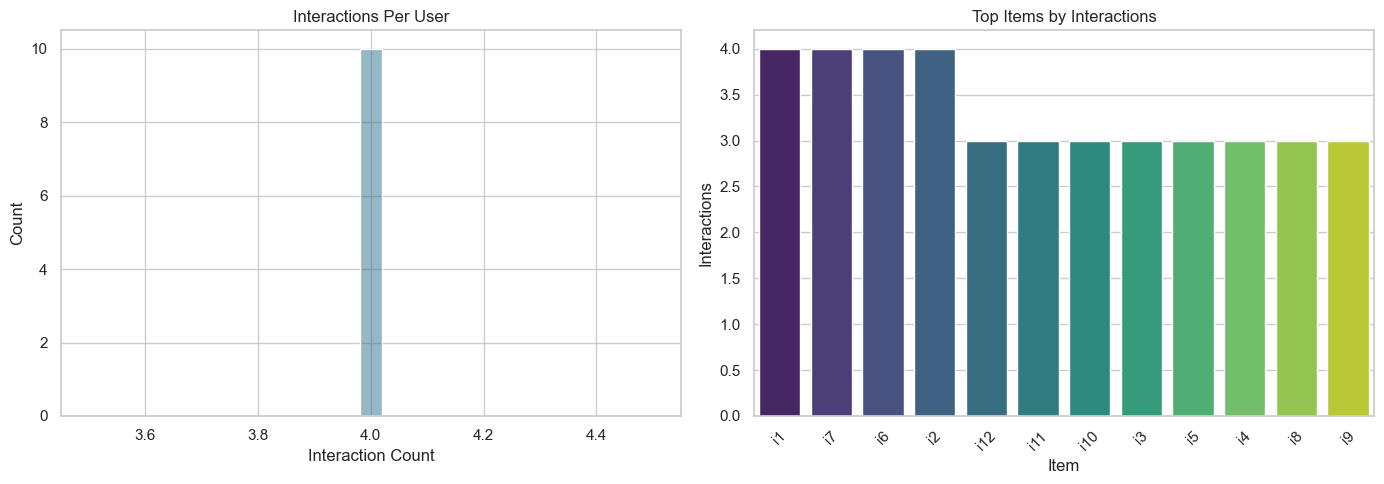

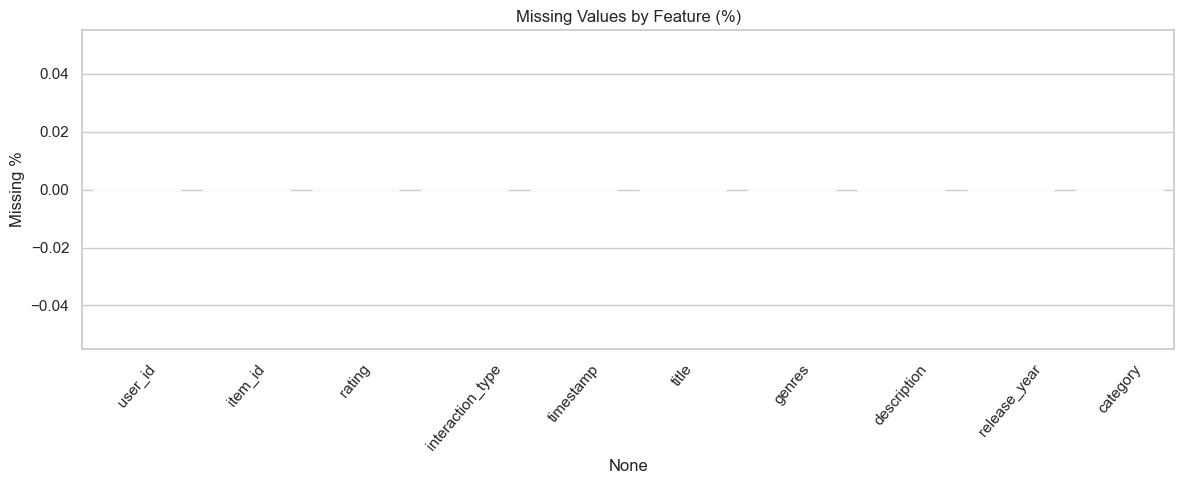

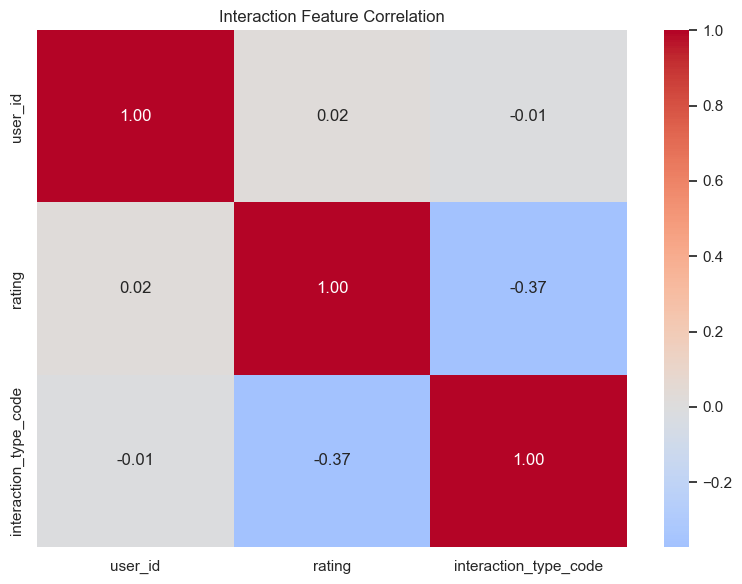

In [3]:
# EDA distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(user_activity, bins=25, kde=True, color='#2D728F', ax=axes[0])
axes[0].set_title('Interactions Per User')
axes[0].set_xlabel('Interaction Count')

top_items = item_popularity.sort_values(ascending=False).head(12)
labels = top_items.index.astype(str)
sns.barplot(x=labels, y=top_items.values, hue=labels, legend=False, palette='viridis', ax=axes[1])
axes[1].set_title('Top Items by Interactions')
axes[1].set_xlabel('Item')
axes[1].set_ylabel('Interactions')
axes[1].tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(assets_dir / 'eda_distribution.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

# Missing values plot
missing_inter = interactions.isna().mean() * 100
missing_items = items.isna().mean() * 100
missing = pd.concat([missing_inter, missing_items]).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=missing.index.astype(str), y=missing.values, color='#4C78A8', ax=ax)
ax.set_title('Missing Values by Feature (%)')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=50)
fig.tight_layout()
fig.savefig(assets_dir / 'missing_values.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

# Correlation heatmap
corr_df = interactions.copy()
corr_df['interaction_type_code'] = corr_df['interaction_type'].astype('category').cat.codes
corr_cols = [c for c in ['user_id', 'rating', 'interaction_type_code'] if c in corr_df.columns]
corr = corr_df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Interaction Feature Correlation')
fig.tight_layout()
fig.savefig(assets_dir / 'correlation_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()
plt.close(fig)

In [4]:
# Generate all portfolio assets and real outputs
manifest = run_portfolio_showcase_pipeline(config)
manifest

{'assets': {'eda_distribution': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\eda_distribution.png',
  'missing_values': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\missing_values.png',
  'correlation_heatmap': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\correlation_heatmap.png',
  'model_comparison': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\model_comparison.png',
  'confusion_matrix': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\confusion_matrix.png',
  'roc_curve': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\roc_curve.png',
  'feature_importance': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\assets\\feature_importance.png',
  'api_response': 'C:\\Users\\jrdhe\\OneDrive\\Documents\\ML_Projects\\recommendation_engine\\a

In [5]:
with (project_root / 'artifacts' / 'metrics.json').open('r', encoding='utf-8') as f:
    metrics = json.load(f)
with (project_root / 'artifacts' / 'output_samples.json').open('r', encoding='utf-8') as f:
    outputs = json.load(f)

display(pd.Series(metrics.get('metrics', {}), name='value').to_frame())
outputs

,value
precision_at_k,0.10000
recall_at_k,1.00000
rmse,1.94698


{'samples': [{'input': {'user_id': 109, 'top_n': 5},
   'output': {'recommendations': ['i4', 'i6', 'i12', 'i10', 'i7'],
    'recommendations_with_scores': [{'item_id': 'i4',
      'predicted_signal': 3.7837,
      'probability_like': 0.7567},
     {'item_id': 'i6', 'predicted_signal': 3.5809, 'probability_like': 0.7162},
     {'item_id': 'i12',
      'predicted_signal': 2.6418,
      'probability_like': 0.5284},
     {'item_id': 'i10',
      'predicted_signal': 2.5994,
      'probability_like': 0.5199},
     {'item_id': 'i7',
      'predicted_signal': 2.5857,
      'probability_like': 0.5171}]}},
  {'input': {'user_id': 102, 'top_n': 5},
   'output': {'recommendations': ['i11', 'i12', 'i10', 'i8', 'i4'],
    'recommendations_with_scores': [{'item_id': 'i11',
      'predicted_signal': 3.5922,
      'probability_like': 0.7184},
     {'item_id': 'i12', 'predicted_signal': 2.667, 'probability_like': 0.5334},
     {'item_id': 'i10',
      'predicted_signal': 2.6214,
      'probability_like'

## Insights

- Hybrid recommendation balances collaborative relevance, semantic content similarity, and popularity fallback.
- Current data is sparse, so cold-start and popularity priors are important for stable ranking quality.
- All visual artifacts and real sample outputs are automatically generated for portfolio demonstration.

# Recommendation Engine EDA

Explore interaction density, item popularity, and sparsity patterns that drive recommender design.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
base_path = Path('../data/raw')
interactions = pd.read_csv(base_path / 'interactions.csv')
items = pd.read_csv(base_path / 'items.csv')
interactions.head()

,user_id,item_id,rating,interaction_type,timestamp
0,101,i1,4,view,2024-01-02 09:00:00
1,101,i2,5,click,2024-01-05 12:10:00
2,101,i6,5,purchase,2024-01-10 18:00:00
3,101,i9,4,rating,2024-01-16 20:30:00
4,102,i3,5,purchase,2024-01-03 11:15:00


In [7]:
# Dataset overview
print(f'Interactions: {interactions.shape[0]} rows, {interactions.shape[1]} columns')
print(f'Items: {items.shape[0]} rows, {items.shape[1]} columns')
display(interactions.info())
display(items.info())
display(interactions.describe(include='all').T)

Interactions: 40 rows, 5 columns
Items: 12 rows, 6 columns
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_id           40 non-null     int64
 1   item_id           40 non-null     str  
 2   rating            40 non-null     int64
 3   interaction_type  40 non-null     str  
 4   timestamp         40 non-null     str  
dtypes: int64(2), str(3)
memory usage: 1.7 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   item_id       12 non-null     str  
 1   title         12 non-null     str  
 2   genres        12 non-null     str  
 3   description   12 non-null     str  
 4   release_year  12 non-null     int64
 5   category      12 non-null     str  
dtypes: int64(1), str(5)
memory usage: 708.0 bytes


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,40.0,NaN,NaN,NaN,105.5,2.908872,101.0,103.0,105.5,108.0,110.0
item_id,40,12,i1,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,40.0,NaN,NaN,NaN,4.425,0.594311,3.0,4.0,4.0,5.0,5.0
interaction_type,40,4,view,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,40,40,2024-01-02 09:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


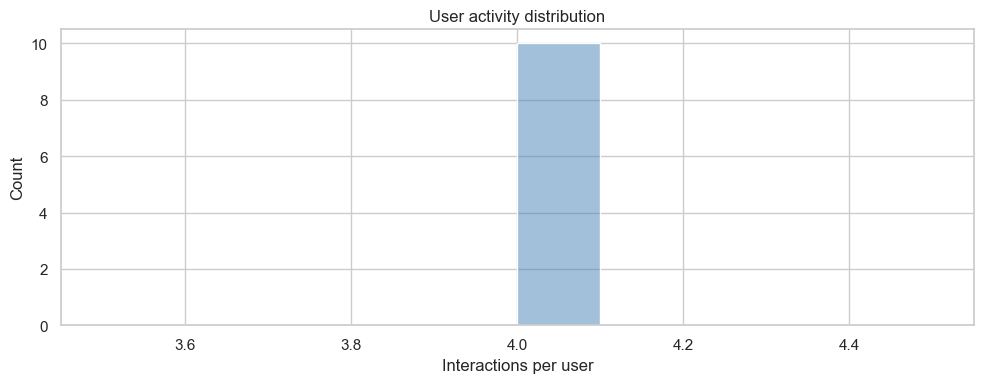

In [8]:
# User activity distribution
activity = interactions.groupby('user_id').size().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
sns.histplot(activity, bins=10, kde=True, color='steelblue')
plt.title('User activity distribution')
plt.xlabel('Interactions per user')
plt.tight_layout()
plt.show()

,interaction_count,avg_rating,title,genres
item_id,,,,
i2,4,4.750000,Skyline Shift,Sci-Fi|Adventure
i7,4,4.750000,Midnight Library,Fantasy|Drama
i6,4,4.500000,Circuit Breaker,Action|Thriller
i1,4,3.750000,The Silent Harbor,Thriller|Drama
i11,3,4.666667,Hidden Signals,Documentary|Tech
i12,3,4.666667,North Star,Comedy|Adventure
i3,3,4.666667,The Last Broadcast,Horror|Mystery
i4,3,4.666667,Coder's Oath,Drama|Tech
i5,3,4.333333,Garden of Echoes,Romance|Drama


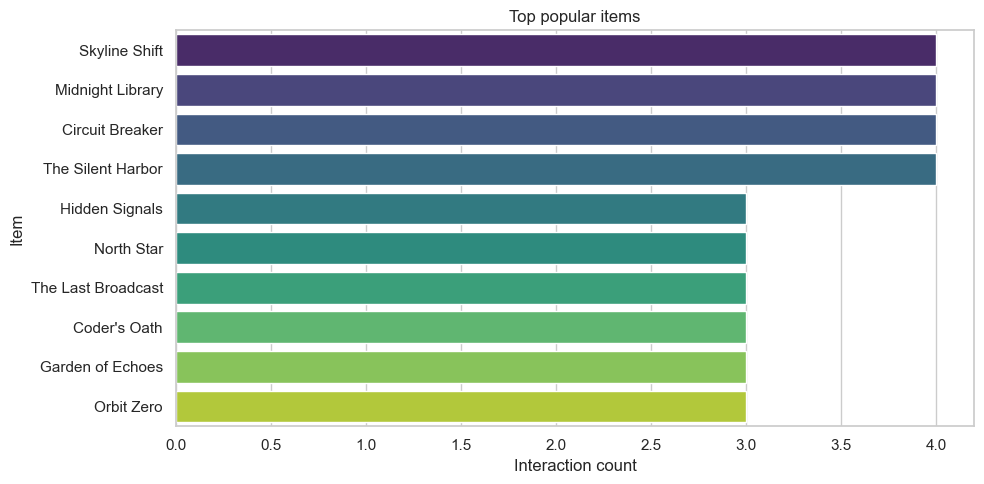

In [12]:
# Popular items
popular = interactions.groupby('item_id').agg(interaction_count=('item_id', 'size'), avg_rating=('rating', 'mean')).sort_values(['interaction_count', 'avg_rating'], ascending=False).head(10)
popular = popular.join(items.set_index('item_id')[['title', 'genres']], how='left')
display(popular)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=popular.reset_index(),
    x='interaction_count',
    y='title',
    hue='title',
    legend=False,
    palette='viridis'
 )
plt.title('Top popular items')
plt.xlabel('Interaction count')
plt.ylabel('Item')
plt.tight_layout()
plt.show()

User-item matrix shape: (10, 12)
Sparsity: 66.67%


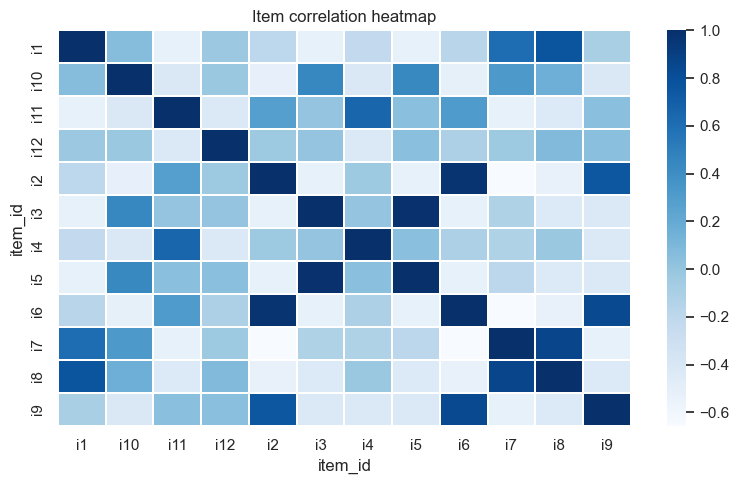

In [10]:
# Sparsity analysis
matrix = interactions.pivot_table(index='user_id', columns='item_id', values='rating', aggfunc='mean', fill_value=0)
sparsity = 1 - (matrix.astype(bool).sum().sum() / (matrix.shape[0] * matrix.shape[1]))
print(f'User-item matrix shape: {matrix.shape}')
print(f'Sparsity: {sparsity:.2%}')
plt.figure(figsize=(8, 5))
sns.heatmap(matrix.corr(), cmap='Blues', linewidths=0.3)
plt.title('Item correlation heatmap')
plt.tight_layout()
plt.show()

## Key Insights

- Sparse user-item matrices make fallback strategies necessary.
- Popular items should remain part of the hybrid scorer.
- Collaborative and content-based signals are both useful when interactions are limited.

Catalog coverage in interactions: 100.00%
Top-20% items share of interactions: 20.00%


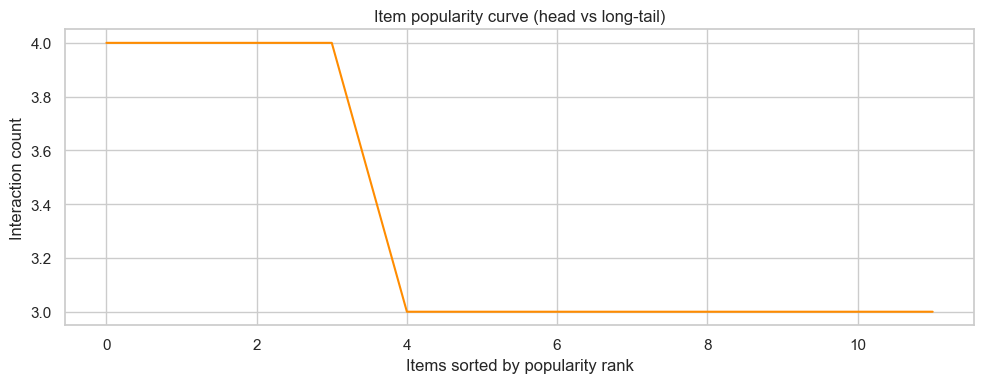

In [11]:
# Recommendation quality diagnostics: catalog coverage and long-tail concentration
item_popularity = interactions.groupby('item_id').size().sort_values(ascending=False)
coverage_ratio = item_popularity.size / items['item_id'].nunique()
head_share = item_popularity.head(max(1, int(0.2 * len(item_popularity)))).sum() / item_popularity.sum()

print(f'Catalog coverage in interactions: {coverage_ratio:.2%}')
print(f'Top-20% items share of interactions: {head_share:.2%}')

plt.figure(figsize=(10, 4))
item_popularity.reset_index(drop=True).plot(kind='line', color='darkorange')
plt.title('Item popularity curve (head vs long-tail)')
plt.xlabel('Items sorted by popularity rank')
plt.ylabel('Interaction count')
plt.tight_layout()
plt.show()

## Recommendation Quality Insights

- A high head-share indicates popularity bias risk, so hybrid blending should preserve some exploration via content and collaborative signals.
- Lower catalog coverage usually means sparse feedback; cold-start defaults and popularity priors become critical.
- These EDA checks justify tuning hybrid weights rather than hardcoding them.